# Qwen3-4B No-CPT SFT: SID-v2 Validation, history window 16

Ablation validation series. The model starts from `Qwen/Qwen3-4B-Base` directly, without the CPT-merged checkpoint.

Protocol:

- train split: `train.parquet` only;
- validation target: `val.parquet`;
- train/eval history length: exactly 16 watched movies;
- target: next watched movie item-level SID;
- loss: target-only, prompt tokens are masked with `-100`;
- decoding: trie-constrained beam search over valid item token sequences;
- early stopping: stop after 2 epochs without Recall@10 improvement.


## 1. Imports and config

Use `DRY_RUN_STEPS = 1` only for a smoke test. For the real run keep `DRY_RUN_STEPS = 0`.


In [1]:
from pathlib import Path
from importlib import metadata
from packaging.version import Version
import inspect
import json
import math
import os
import random
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm

from transformers import AutoModelForCausalLM, AutoTokenizer, Trainer, TrainingArguments
from peft import LoraConfig, PeftModel, TaskType, get_peft_model

os.environ.setdefault("HF_HUB_DISABLE_SYMLINKS_WARNING", "1")

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

RUN_NAME = "sft_qwen3_4b_no_cpt_sid_v2_next_watch_w16_pat2_v1"
BASE_CPT_DIR = Path(os.environ.get("QWEN3_4B_BASE_DIR", r"C:\Users\User\.cache\huggingface\hub\models--Qwen--Qwen3-4B-Base\snapshots\906bfd4b4dc7f14ee4320094d8b41684abff8539"))
SID_ARRAY_PATH = ROOT / "runs/qwen4b_rqvae_sid_v2_plum/SIDs_best.npy"
TRAIN_PATH = ROOT / "data/processed/splits/train.parquet"
VAL_PATH = ROOT / "data/processed/splits/val.parquet"
TEST_PATH = ROOT / "data/processed/splits/test.parquet"
USERS_PATH = ROOT / "data/raw/ml-1m/users.dat"

OUTPUT_DIR = ROOT / "data/processed/artifacts" / RUN_NAME
TMP_TRAINER_DIR = OUTPUT_DIR / "trainer_tmp"
BEST_ADAPTER_DIR = OUTPUT_DIR / "best_adapter"
LAST_ADAPTER_DIR = OUTPUT_DIR / "last_adapter"
BEST_MERGED_DIR = OUTPUT_DIR / "best_merged"

SEED = 42
MAX_EPOCHS = 10
MIN_EPOCHS = 3
EARLY_STOPPING_PATIENCE = 2
PRIMARY_METRIC = "recall@10"

MIN_HISTORY_LEN = 16
TRAIN_HISTORY_WINDOW_CHOICES = [16]
EVAL_HISTORY_LEN = 16
TARGETS_PER_USER_PER_EPOCH = 4
RECENT_TARGET_FRACTION = 0.65
INCLUDE_RATINGS = True
INCLUDE_USER_FEATURES = True
FILTER_SEEN = True

MAX_SEQ_LENGTH = 192
MAX_TARGET_TOKENS = 8
TOP_K = 10
EVAL_BEAM_SIZE = 20
EVAL_NUM_RETURN_SEQUENCES = 20
EVAL_MAX_USERS = 256
FULL_EVAL_MAX_USERS = None
RUN_FINAL_FULL_VAL = False
RUN_TEST_EVAL = False

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
LEARNING_RATE = 1e-4
WARMUP_RATIO = 0.03
WEIGHT_DECAY = 0.01
PER_DEVICE_BATCH = 8
GRADIENT_ACCUMULATION_STEPS = 8
LOGGING_STEPS = 20
SAVE_MERGED_BEST = False
DRY_RUN_STEPS = 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
FP16 = DEVICE == "cuda" and not BF16
DTYPE = torch.bfloat16 if BF16 else (torch.float16 if FP16 else torch.float32)
PRECISION_MODE = "bf16" if BF16 else ("fp16" if FP16 else "fp32")

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.cuda.empty_cache()

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("root:", ROOT)
print("base model:", BASE_CPT_DIR)
print("device:", DEVICE, PRECISION_MODE)
print("effective batch:", PER_DEVICE_BATCH * GRADIENT_ACCUMULATION_STEPS)

root: C:\Users\User\plum-ml1m-repro
base model: C:\Users\User\.cache\huggingface\hub\models--Qwen--Qwen3-4B-Base\snapshots\906bfd4b4dc7f14ee4320094d8b41684abff8539
device: cuda bf16
effective batch: 64


## 2. Load data

SFT training uses only train interactions. Validation target is `val.parquet`; test is not used here.


In [2]:
assert BASE_CPT_DIR.exists(), BASE_CPT_DIR
train = pd.read_parquet(TRAIN_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
val = pd.read_parquet(VAL_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
test = pd.read_parquet(TEST_PATH).sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").reset_index(drop=True)
users = pd.read_csv(
    USERS_PATH,
    sep="::",
    engine="python",
    names=["user_id", "gender", "age", "occupation", "zip"],
    encoding="latin-1",
)
sids = np.load(SID_ARRAY_PATH)

print("train/val/test:", len(train), len(val), len(test))
print("users:", len(users), "items:", len(sids))
train.head()

train/val/test: 988129 6040 6040
users: 6040 items: 3706


,user_id,movie_id,rating,timestamp,user_idx,item_idx,pos,len
0,1,3186,4,978300019,0,2969,0,53
1,1,1270,5,978300055,0,1178,1,53
2,1,1721,4,978300055,0,1574,2,53
3,1,1022,5,978300055,0,957,3,53
4,1,2340,3,978300103,0,2147,4,53


## 3. Tokenizer, SID tokens, and collision suffixes

SID collisions are rare, but suffixes keep target sequences item-level unique.

In [3]:
BOS = "<bos>"
EOS = "<eos>"
PAD = "<pad>"
USER_OPEN = "<user>"
USER_CLOSE = "</user>"
HIST = "<hist>"
EVENT_OPEN = "<e>"
EVENT_CLOSE = "</e>"
TASK_REC = "<task_rec>"
NEXT = "<next>"


def base_sid_tokens(sid):
    return [f"<sid_{level}_{int(code)}>" for level, code in enumerate(sid)]


def rating_token(rating):
    return f"<rat_{int(rating)}>"


def user_tokens(row):
    return [f"<gen_{row.gender}>", f"<age_{int(row.age)}>", f"<occ_{int(row.occupation)}>"]

sid_keys = [tuple(int(x) for x in sid) for sid in sids]
sid_to_items = {}
for item_idx, key in enumerate(sid_keys):
    sid_to_items.setdefault(key, []).append(int(item_idx))

item_dup_suffix = {}
dup_tokens = []
for key, items in sid_to_items.items():
    if len(items) > 1:
        for dup_i, item_idx in enumerate(sorted(items)):
            tok = f"<dup_{dup_i}>"
            item_dup_suffix[int(item_idx)] = tok
            dup_tokens.append(tok)

def item_sid_tokens(item_idx):
    tokens = base_sid_tokens(sids[int(item_idx)])
    if int(item_idx) in item_dup_suffix:
        tokens = tokens + [item_dup_suffix[int(item_idx)]]
    return tokens


def load_tokenizer(path):
    try:
        return AutoTokenizer.from_pretrained(path, use_fast=True, fix_mistral_regex=True, local_files_only=True)
    except TypeError:
        return AutoTokenizer.from_pretrained(path, use_fast=True, local_files_only=True)


tokenizer = load_tokenizer(BASE_CPT_DIR)
base_vocab_size = len(tokenizer)

codebook_sizes = [1024, 512, 256, 128]
sid_vocab = [f"<sid_{level}_{code}>" for level, size in enumerate(codebook_sizes) for code in range(size)]
rating_vocab = [f"<rat_{rating}>" for rating in sorted(train["rating"].unique().tolist())]
user_vocab = (
    [f"<gen_{gender}>" for gender in sorted(users["gender"].unique().tolist())]
    + [f"<age_{int(age)}>" for age in sorted(users["age"].unique().tolist())]
    + [f"<occ_{int(occupation)}>" for occupation in sorted(users["occupation"].unique().tolist())]
)
prompt_vocab = [BOS, EOS, PAD, USER_OPEN, USER_CLOSE, HIST, EVENT_OPEN, EVENT_CLOSE, TASK_REC, NEXT]
extra_tokens = sorted(set(prompt_vocab + sid_vocab + rating_vocab + user_vocab + dup_tokens))
added = tokenizer.add_tokens([tok for tok in extra_tokens if tok not in tokenizer.get_vocab()], special_tokens=True)
tokenizer.bos_token = BOS
tokenizer.eos_token = EOS
tokenizer.pad_token = PAD
new_token_ids = sorted(set(int(x) for x in tokenizer.convert_tokens_to_ids(extra_tokens)))

print("base vocab:", base_vocab_size, "current vocab:", len(tokenizer), "added:", added)
print("SID collisions:", sum(len(v) > 1 for v in sid_to_items.values()), "dup items:", len(item_dup_suffix))
print("new trainable token ids:", len(new_token_ids))


base vocab: 151669 current vocab: 153636 added: 1967
SID collisions: 11 dup items: 22
new trainable token ids: 1967


## 4. Build trie and item maps

The trie constrains generation to valid item token sequences only.

In [4]:
def token_ids_for_item(item_idx):
    return tuple(int(x) for x in tokenizer.convert_tokens_to_ids(item_sid_tokens(item_idx)))

item_to_token_ids = {int(i): token_ids_for_item(i) for i in range(len(sids))}
token_ids_to_item = {v: k for k, v in item_to_token_ids.items()}
assert len(token_ids_to_item) == len(item_to_token_ids)

TRIE = {}
for ids in item_to_token_ids.values():
    node = TRIE
    for token_id in ids:
        node = node.setdefault(int(token_id), {})
    node[int(tokenizer.eos_token_id)] = {}

EOS_ID = int(tokenizer.eos_token_id)
PAD_ID = int(tokenizer.pad_token_id)
print("valid item sequences:", len(item_to_token_ids))
print("max target tokens:", max(len(x) for x in item_to_token_ids.values()) + 1)

valid item sequences: 3706
max target tokens: 6


## 5. Prompt and example encoding

In [5]:
users_by_id = users.set_index("user_id", drop=False)

train_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in train.groupby("user_id", sort=False)
}

val_target_by_user = {
    int(row.user_id): row._asdict()
    for row in val.sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").itertuples(index=False)
}

test_target_by_user = {
    int(row.user_id): row._asdict()
    for row in test.sort_values(["user_idx", "timestamp", "pos", "item_idx"], kind="mergesort").itertuples(index=False)
}

train_plus_val_events_by_user = {
    int(user_id): group.sort_values(["timestamp", "pos", "item_idx"], kind="mergesort").to_dict("records")
    for user_id, group in pd.concat([train, val], ignore_index=True).groupby("user_id", sort=False)
}


def event_tokens(event):
    tokens = [EVENT_OPEN]
    tokens.extend(item_sid_tokens(event["item_idx"]))
    if INCLUDE_RATINGS:
        tokens.append(rating_token(event["rating"]))
    tokens.append(EVENT_CLOSE)
    return tokens


def prompt_prefix_tokens(user_id):
    tokens = [BOS, TASK_REC]
    if INCLUDE_USER_FEATURES and int(user_id) in users_by_id.index:
        tokens.append(USER_OPEN)
        tokens.extend(user_tokens(users_by_id.loc[int(user_id)]))
        tokens.append(USER_CLOSE)
    tokens.append(HIST)
    return tokens


def fit_prompt(prefix, history_events, target_tokens):
    event_blocks = [event_tokens(event) for event in history_events]
    while event_blocks:
        prompt_tokens = prefix + [tok for block in event_blocks for tok in block] + [NEXT]
        if len(prompt_tokens) + len(target_tokens) <= MAX_SEQ_LENGTH:
            return prompt_tokens
        event_blocks = event_blocks[1:]
    prompt_tokens = prefix + [NEXT]
    if len(prompt_tokens) + len(target_tokens) > MAX_SEQ_LENGTH:
        raise ValueError("Prompt prefix plus target exceeds MAX_SEQ_LENGTH")
    return prompt_tokens


def encode_sft_example(user_id, history_events, target_event, split):
    target_item = int(target_event["item_idx"])
    target_tokens = item_sid_tokens(target_item) + [EOS]
    prompt_tokens = fit_prompt(prompt_prefix_tokens(user_id), history_events, target_tokens)
    all_tokens = prompt_tokens + target_tokens
    input_ids = tokenizer.convert_tokens_to_ids(all_tokens)
    labels = [-100] * len(prompt_tokens) + input_ids[len(prompt_tokens):]

    if any(token_id == tokenizer.unk_token_id for token_id in input_ids):
        bad = [tok for tok, token_id in zip(all_tokens, input_ids) if token_id == tokenizer.unk_token_id]
        raise ValueError(f"Unknown tokens: {bad[:10]}")

    return {
        "input_ids": input_ids,
        "labels": labels,
        "prompt_length": len(prompt_tokens),
        "user_id": int(user_id),
        "split": split,
        "target_item_idx": target_item,
        "history_item_idx": [int(event["item_idx"]) for event in history_events],
    }

## 6. Dynamic train sampler

Each epoch resamples target positions. Every example uses exactly 16 history events.


In [6]:
def sample_target_positions(n_events, rng):
    valid = np.arange(MIN_HISTORY_LEN, n_events, dtype=np.int32)
    if len(valid) == 0:
        return []

    n_recent = int(round(TARGETS_PER_USER_PER_EPOCH * RECENT_TARGET_FRACTION))
    n_random = TARGETS_PER_USER_PER_EPOCH - n_recent
    recent_pool_start = max(MIN_HISTORY_LEN, int(n_events * 0.70))
    recent_pool = np.arange(recent_pool_start, n_events, dtype=np.int32)
    if len(recent_pool) == 0:
        recent_pool = valid

    recent = rng.choice(recent_pool, size=min(n_recent, len(recent_pool)), replace=len(recent_pool) < n_recent)
    random_pos = rng.choice(valid, size=min(n_random, len(valid)), replace=len(valid) < n_random)
    return sorted(set(int(x) for x in np.concatenate([recent, random_pos])))


def build_train_examples_for_epoch(epoch):
    rng = np.random.default_rng(SEED + epoch)
    examples = []
    stats = []

    for user_id, events in train_events_by_user.items():
        positions = sample_target_positions(len(events), rng)
        for target_pos in positions:
            target_event = events[target_pos]
            window = int(rng.choice(TRAIN_HISTORY_WINDOW_CHOICES))
            start = max(0, target_pos - window)
            history_events = events[start:target_pos]
            if len(history_events) < MIN_HISTORY_LEN:
                continue
            ex = encode_sft_example(user_id, history_events, target_event, split="train")
            examples.append(ex)
            stats.append((len(history_events), len(ex["input_ids"])))

    rng.shuffle(examples)
    stats = np.array(stats, dtype=np.int32) if stats else np.zeros((0, 2), dtype=np.int32)
    epoch_stats = {
        "epoch": int(epoch),
        "examples": int(len(examples)),
        "history_p50": int(np.percentile(stats[:, 0], 50)) if len(stats) else 0,
        "history_p95": int(np.percentile(stats[:, 0], 95)) if len(stats) else 0,
        "length_p50": int(np.percentile(stats[:, 1], 50)) if len(stats) else 0,
        "length_p95": int(np.percentile(stats[:, 1], 95)) if len(stats) else 0,
        "length_max": int(stats[:, 1].max()) if len(stats) else 0,
    }
    return examples, epoch_stats

train_preview, train_preview_stats = build_train_examples_for_epoch(0)
train_preview_stats

{'epoch': 0,
 'examples': 23341,
 'history_p50': 16,
 'history_p95': 16,
 'length_p50': 126,
 'length_p95': 126,
 'length_max': 130}

## 7. Eval examples

Validation uses train history as context and val item as target. Test uses train+val as context and test item as target.

In [7]:
def build_eval_examples(split="val", max_users=None, seed=SEED):
    if split == "val":
        context_by_user = train_events_by_user
        target_by_user = val_target_by_user
    elif split == "test":
        context_by_user = train_plus_val_events_by_user
        target_by_user = test_target_by_user
    else:
        raise ValueError("split must be 'val' or 'test'")

    user_ids = sorted(target_by_user.keys())
    if max_users is not None:
        rng = np.random.default_rng(seed)
        user_ids = sorted(rng.choice(user_ids, size=min(max_users, len(user_ids)), replace=False).tolist())

    examples = []
    for user_id in user_ids:
        history = context_by_user.get(int(user_id), [])[-EVAL_HISTORY_LEN:]
        if len(history) < MIN_HISTORY_LEN:
            continue
        examples.append(encode_sft_example(user_id, history, target_by_user[user_id], split=split))
    return examples

val_examples = build_eval_examples("val", max_users=EVAL_MAX_USERS)
full_val_examples = build_eval_examples("val", max_users=FULL_EVAL_MAX_USERS)
print("sample val:", len(val_examples), "full val:", len(full_val_examples))

sample val: 256 full val: 6040


## 8. Dataset and collator

In [8]:
class SFTListDataset(Dataset):
    def __init__(self, examples):
        self.examples = examples

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {"input_ids": ex["input_ids"], "labels": ex["labels"]}


class SFTCollator:
    def __init__(self, tokenizer, pad_to_multiple_of=8):
        self.tokenizer = tokenizer
        self.pad_to_multiple_of = pad_to_multiple_of

    def __call__(self, features):
        max_len = max(len(f["input_ids"]) for f in features)
        if self.pad_to_multiple_of:
            max_len = int(math.ceil(max_len / self.pad_to_multiple_of) * self.pad_to_multiple_of)

        input_ids, labels, attention_mask = [], [], []
        for f in features:
            ids = list(f["input_ids"])
            lab = list(f["labels"])
            pad_len = max_len - len(ids)
            input_ids.append(ids + [self.tokenizer.pad_token_id] * pad_len)
            labels.append(lab + [-100] * pad_len)
            attention_mask.append([1] * len(ids) + [0] * pad_len)

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
        }

collator = SFTCollator(tokenizer)

## 9. Load Qwen CPT and attach SFT LoRA

In [9]:
def load_causal_lm(path):
    kwargs = {"dtype": DTYPE, "local_files_only": True, "trust_remote_code": False}
    try:
        return AutoModelForCausalLM.from_pretrained(path, **kwargs)
    except TypeError:
        kwargs["torch_dtype"] = kwargs.pop("dtype")
        return AutoModelForCausalLM.from_pretrained(path, **kwargs)

model = load_causal_lm(BASE_CPT_DIR)
model.resize_token_embeddings(len(tokenizer), mean_resizing=False)
model.config.bos_token_id = tokenizer.bos_token_id
model.config.eos_token_id = tokenizer.eos_token_id
model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})
if hasattr(model, "enable_input_require_grads"):
    model.enable_input_require_grads()

lora_kwargs = {
    "task_type": TaskType.CAUSAL_LM,
    "r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "lora_dropout": LORA_DROPOUT,
    "bias": "none",
    "target_modules": ["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    "trainable_token_indices": {"embed_tokens": new_token_ids, "lm_head": new_token_ids},
}
peft_config = LoraConfig(**lora_kwargs)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()
model.to(DEVICE)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

trainable params: 38,065,664 || all params: 4,064,885,760 || trainable%: 0.9365


PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen3ForCausalLM(
      (model): Qwen3Model(
        (embed_tokens): TrainableTokensWrapper(
          (original_module): None
          (token_adapter): TrainableTokensLayer(
            (base_layer): Embedding(153636, 2560)
            (trainable_tokens_delta): ParameterDict(  (default): Parameter containing: [torch.cuda.FloatTensor of size 1967x2560 (cuda:0)])
            (trainable_tokens_original): BufferDict(  (default): Buffer containing: [torch.cuda.FloatTensor of size 1967x2560 (CUDA 0)])
          )
        )
        (layers): ModuleList(
          (0-35): 36 x Qwen3DecoderLayer(
            (self_attn): Qwen3Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=2560, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                 

## 10. Trie decoding and metrics

In [10]:
def set_generation_mode(model):
    model.eval()
    model.config.use_cache = True
    if hasattr(model, "gradient_checkpointing_disable"):
        model.gradient_checkpointing_disable()
    torch.cuda.empty_cache() if DEVICE == "cuda" else None


def set_training_mode(model):
    model.train()
    model.config.use_cache = False
    if hasattr(model, "gradient_checkpointing_enable"):
        model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})


def trie_allowed_tokens(prompt_length):
    def allowed(_batch_id, input_ids):
        node = TRIE
        generated = input_ids[prompt_length:].tolist()
        for token_id in generated:
            token_id = int(token_id)
            if token_id not in node:
                return [EOS_ID]
            node = node[token_id]
        return sorted(node.keys()) if node else [EOS_ID]
    return allowed


def decode_generated_item(sequence_ids, prompt_length):
    new_ids = []
    for token_id in sequence_ids[prompt_length:].tolist():
        token_id = int(token_id)
        if token_id in {EOS_ID, PAD_ID}:
            break
        new_ids.append(token_id)
    return token_ids_to_item.get(tuple(new_ids))


def generate_candidates(model, example, beam_size=EVAL_BEAM_SIZE, top_k=TOP_K, num_return_sequences=EVAL_NUM_RETURN_SEQUENCES, filter_seen=FILTER_SEEN):
    prompt_ids = example["input_ids"][:example["prompt_length"]]
    input_ids = torch.tensor([prompt_ids], dtype=torch.long, device=DEVICE)
    attention_mask = torch.ones_like(input_ids)
    seen = set(example.get("history_item_idx", [])) if filter_seen else set()
    num_return_sequences = min(int(num_return_sequences), int(beam_size))

    with torch.inference_mode():
        outputs = model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=MAX_TARGET_TOKENS,
            num_beams=beam_size,
            num_return_sequences=num_return_sequences,
            do_sample=False,
            early_stopping=True,
            pad_token_id=PAD_ID,
            eos_token_id=EOS_ID,
            prefix_allowed_tokens_fn=trie_allowed_tokens(len(prompt_ids)),
            use_cache=True,
        )

    candidates = []
    raw_items = []
    invalid = 0
    seen_generated = 0
    used = set()

    for seq in outputs:
        item = decode_generated_item(seq, len(prompt_ids))
        if item is None:
            invalid += 1
            continue
        raw_items.append(int(item))
        if item in seen:
            seen_generated += 1
            continue
        if item in used:
            continue
        candidates.append(int(item))
        used.add(int(item))
        if len(candidates) >= top_k:
            break

    return {"candidates": candidates, "raw_items": raw_items, "invalid_sid_count": invalid, "seen_generated_count": seen_generated, "generated_count": int(len(outputs))}


def recall_at_k(candidates, target, k):
    return float(int(int(target) in candidates[:k]))


def ndcg_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / math.log2(rank + 1)
    return 0.0


def mrr_at_k(candidates, target, k):
    target = int(target)
    for rank, item in enumerate(candidates[:k], start=1):
        if int(item) == target:
            return 1.0 / rank
    return 0.0


def evaluate_model(model, examples, name="val", beam_size=EVAL_BEAM_SIZE, top_k=TOP_K, num_return_sequences=EVAL_NUM_RETURN_SEQUENCES):
    set_generation_mode(model)
    records = []
    for ex in tqdm(examples, desc=f"eval {name}", leave=False):
        gen = generate_candidates(model, ex, beam_size=beam_size, top_k=top_k, num_return_sequences=num_return_sequences)
        records.append({"user_id": ex["user_id"], "target_item_idx": int(ex["target_item_idx"]), **gen})

    metrics = {"split": name, "n": len(records)}
    recommended = set()
    invalid = 0
    generated = 0
    seen_generated = 0
    candidate_counts = []

    for rec in records:
        target = int(rec["target_item_idx"])
        candidates = rec["candidates"]
        recommended.update(candidates)
        candidate_counts.append(len(candidates))
        invalid += int(rec["invalid_sid_count"])
        generated += int(rec["generated_count"])
        seen_generated += int(rec["seen_generated_count"])
        for k in [1, 5, 10]:
            metrics[f"recall@{k}"] = metrics.get(f"recall@{k}", 0.0) + recall_at_k(candidates, target, k)
            metrics[f"ndcg@{k}"] = metrics.get(f"ndcg@{k}", 0.0) + ndcg_at_k(candidates, target, k)
            metrics[f"mrr@{k}"] = metrics.get(f"mrr@{k}", 0.0) + mrr_at_k(candidates, target, k)

    n = max(len(records), 1)
    for key in list(metrics):
        if key.startswith(("recall@", "ndcg@", "mrr@")):
            metrics[key] = metrics[key] / n
    metrics["coverage@10"] = int(len(recommended))
    metrics["avg_candidates"] = float(np.mean(candidate_counts)) if candidate_counts else 0.0
    metrics["invalid_sid_rate"] = float(invalid / max(generated, 1))
    metrics["seen_generated_rate"] = float(seen_generated / max(generated, 1))
    return metrics, records

## 11. Training helpers

In [11]:
def make_training_args(epoch):
    args_kwargs = {
        "output_dir": str(TMP_TRAINER_DIR / f"epoch_{epoch:03d}"),
        "overwrite_output_dir": True,
        "num_train_epochs": 1,
        "max_steps": DRY_RUN_STEPS if DRY_RUN_STEPS > 0 else -1,
        "learning_rate": LEARNING_RATE,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "per_device_train_batch_size": PER_DEVICE_BATCH,
        "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
        "gradient_checkpointing": True,
        "logging_steps": LOGGING_STEPS,
        "save_strategy": "no",
        "eval_strategy": "no",
        "fp16": FP16,
        "bf16": BF16,
        "tf32": DEVICE == "cuda",
        "report_to": "none",
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": DEVICE == "cuda",
        "remove_unused_columns": False,
        "optim": "adamw_torch_fused" if DEVICE == "cuda" else "adamw_torch",
    }
    args_params = inspect.signature(TrainingArguments).parameters
    return TrainingArguments(**{k: v for k, v in args_kwargs.items() if k in args_params})


def save_adapter_bundle(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    model.save_pretrained(str(path))
    tokenizer.save_pretrained(str(path))


def merge_best_adapter(adapter_dir=BEST_ADAPTER_DIR, merged_dir=BEST_MERGED_DIR):
    adapter_dir = Path(adapter_dir)
    merged_dir = Path(merged_dir)
    tok = load_tokenizer(adapter_dir)
    base = load_causal_lm(BASE_CPT_DIR)
    base.resize_token_embeddings(len(tok), mean_resizing=False)
    peft_model = PeftModel.from_pretrained(base, adapter_dir).to(DEVICE)
    merged = peft_model.merge_and_unload()
    merged_dir.mkdir(parents=True, exist_ok=True)
    merged.save_pretrained(str(merged_dir), safe_serialization=True, max_shard_size="2GB")
    tok.save_pretrained(str(merged_dir))
    return merged_dir

## 12. Train SFT

This cell runs full training when `DRY_RUN_STEPS = 0`. For smoke, set `DRY_RUN_STEPS = 1` and reduce `EVAL_MAX_USERS` before rebuilding eval examples.

In [12]:
metrics_log = []
best_metric = -1.0
best_epoch = 0
bad_epochs = 0
started_at = time.time()

for epoch in range(1, MAX_EPOCHS + 1):
    set_training_mode(model)
    train_examples, epoch_data_stats = build_train_examples_for_epoch(epoch)
    train_ds = SFTListDataset(train_examples)

    trainer_kwargs = {
        "model": model,
        "args": make_training_args(epoch),
        "train_dataset": train_ds,
        "data_collator": collator,
    }
    trainer_params = inspect.signature(Trainer).parameters
    if "processing_class" in trainer_params:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)
    train_output = trainer.train()

    eval_name = f"val_sample_{len(val_examples)}"
    eval_metrics, _ = evaluate_model(model, val_examples, name=eval_name)
    current = float(eval_metrics[PRIMARY_METRIC])
    improved = current > best_metric

    if improved:
        best_metric = current
        best_epoch = epoch
        bad_epochs = 0
        save_adapter_bundle(BEST_ADAPTER_DIR)
    else:
        bad_epochs += 1

    row = {
        "epoch": epoch,
        "train_loss": float(train_output.metrics.get("train_loss", np.nan)),
        "train_runtime": float(train_output.metrics.get("train_runtime", np.nan)),
        "best_epoch": best_epoch,
        "best_metric": best_metric,
        "bad_epochs": bad_epochs,
        "improved": bool(improved),
        **epoch_data_stats,
        **{f"eval_{k}": v for k, v in eval_metrics.items() if k not in {"split"}},
    }
    metrics_log.append(row)
    pd.DataFrame(metrics_log).to_json(OUTPUT_DIR / "metrics.json", orient="records", indent=2)
    print(json.dumps(row, indent=2))

    if DRY_RUN_STEPS > 0:
        print("DRY_RUN_STEPS > 0: stopping after smoke epoch.")
        break
    if epoch >= MIN_EPOCHS and bad_epochs >= EARLY_STOPPING_PATIENCE:
        print("early stopping")
        break

save_adapter_bundle(LAST_ADAPTER_DIR)
summary = {
    "best_epoch": best_epoch,
    "best_metric": best_metric,
    "best_adapter_dir": str(BEST_ADAPTER_DIR),
    "last_adapter_dir": str(LAST_ADAPTER_DIR),
    "epochs_completed": len(metrics_log),
    "train_seconds": time.time() - started_at,
}
with (OUTPUT_DIR / "summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

if SAVE_MERGED_BEST and DRY_RUN_STEPS == 0:
    summary["best_merged_dir"] = str(merge_best_adapter())
    with (OUTPUT_DIR / "summary.json").open("w", encoding="utf-8") as f:
        json.dump(summary, f, ensure_ascii=False, indent=2)

summary

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151682, 'bos_token_id': 151678, 'pad_token_id': 151708}.


Step,Training Loss
20,10.180200
40,4.868500
60,3.739500
80,3.401000
100,3.307800
120,3.198300
140,3.113300
160,3.100300
180,3.052500
200,2.977700


eval val_sample_256:   0%|          | 0/256 [00:00<?, ?it/s]

C:\Users\User\.conda\conda.new\Lib\site-packages\peft\utils\save_and_load.py:386: UserWarning: Setting `save_embedding_layers` to `True` as the embedding layer has been resized during finetuning.
  warnings.warn(


{
  "epoch": 1,
  "train_loss": 3.4675427214740075,
  "train_runtime": 1567.2532,
  "best_epoch": 1,
  "best_metric": 0.0546875,
  "bad_epochs": 0,
  "improved": true,
  "examples": 23298,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 129,
  "eval_n": 256,
  "eval_recall@1": 0.00390625,
  "eval_ndcg@1": 0.00390625,
  "eval_mrr@1": 0.00390625,
  "eval_recall@5": 0.01953125,
  "eval_ndcg@5": 0.012230194349888507,
  "eval_mrr@5": 0.009765625,
  "eval_recall@10": 0.0546875,
  "eval_ndcg@10": 0.023661753637585232,
  "eval_mrr@10": 0.014522879464285713,
  "eval_coverage@10": 322,
  "eval_avg_candidates": 10.0,
  "eval_invalid_sid_rate": 0.0,
  "eval_seen_generated_rate": 0.0755859375
}


...

{
  "epoch": 9,
  "train_loss": 1.3449864518152523,
  "train_runtime": 1577.701,
  "best_epoch": 9,
  "best_metric": 0.1640625,
  "bad_epochs": 0,
  "improved": true,
  "examples": 23334,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 130,
  "eval_n": 256,
  "eval_recall@1": 0.0078125,
  "eval_ndcg@1": 0.0078125,
  "eval_mrr@1": 0.0078125,
  "eval_recall@5": 0.09375,
  "eval_ndcg@5": 0.04801089773916142,
  "eval_mrr@5": 0.03326822916666666,
  "eval_recall@10": 0.1640625,
  "eval_ndcg@10": 0.07111059889956202,
  "eval_mrr@10": 0.04301215277777777,
  "eval_coverage@10": 688,
  "eval_avg_candidates": 10.0,
  "eval_invalid_sid_rate": 0.0,
  "eval_seen_generated_rate": 0.1046875
}


Step,Training Loss
20,1.313000
40,1.408900
60,1.379600
80,1.379900
100,1.399900
120,1.366800
140,1.359400
160,1.360500
180,1.356300
200,1.317600


eval val_sample_256:   0%|          | 0/256 [00:00<?, ?it/s]

{
  "epoch": 10,
  "train_loss": 1.3295846586358058,
  "train_runtime": 1622.2673,
  "best_epoch": 9,
  "best_metric": 0.1640625,
  "bad_epochs": 1,
  "improved": false,
  "examples": 23358,
  "history_p50": 16,
  "history_p95": 16,
  "length_p50": 126,
  "length_p95": 126,
  "length_max": 130,
  "eval_n": 256,
  "eval_recall@1": 0.015625,
  "eval_ndcg@1": 0.015625,
  "eval_mrr@1": 0.015625,
  "eval_recall@5": 0.08984375,
  "eval_ndcg@5": 0.05444695239394772,
  "eval_mrr@5": 0.04270833333333332,
  "eval_recall@10": 0.15234375,
  "eval_ndcg@10": 0.07456393214936889,
  "eval_mrr@10": 0.050964161706349195,
  "eval_coverage@10": 712,
  "eval_avg_candidates": 10.0,
  "eval_invalid_sid_rate": 0.0,
  "eval_seen_generated_rate": 0.084375
}


{'best_epoch': 9,
 'best_metric': 0.1640625,
 'best_adapter_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_4b_no_cpt_sid_v2_next_watch_w16_pat2_v1\\best_adapter',
 'last_adapter_dir': 'C:\\Users\\User\\plum-ml1m-repro\\data\\processed\\artifacts\\sft_qwen3_4b_no_cpt_sid_v2_next_watch_w16_pat2_v1\\last_adapter',
 'epochs_completed': 10,
 'train_seconds': 18032.03925561905}

## 13. Optional full validation on best adapter

Keep this off during tuning. Qwen generation over all 6040 validation users can be slow.

In [13]:
RUN_FINAL_FULL_VAL = False

print("RUN_FINAL_FULL_VAL:", RUN_FINAL_FULL_VAL)
print("BEST_ADAPTER_DIR:", BEST_ADAPTER_DIR)
print("best exists:", BEST_ADAPTER_DIR.exists())
print("full val examples:", len(full_val_examples))

RUN_FINAL_FULL_VAL: False
BEST_ADAPTER_DIR: C:\Users\User\plum-ml1m-repro\data\processed\artifacts\sft_qwen3_4b_no_cpt_sid_v2_next_watch_w16_pat2_v1\best_adapter
best exists: True
full val examples: 6040


In [14]:
full_val_metrics = None
if RUN_FINAL_FULL_VAL and BEST_ADAPTER_DIR.exists():
    tokenizer = load_tokenizer(BEST_ADAPTER_DIR)
    base = load_causal_lm(BASE_CPT_DIR)
    base.resize_token_embeddings(len(tokenizer), mean_resizing=False)
    eval_model = PeftModel.from_pretrained(base, BEST_ADAPTER_DIR).to(DEVICE)
    full_val_metrics, _ = evaluate_model(eval_model, full_val_examples, name="val_full_best")
    with (OUTPUT_DIR / "full_val_metrics.json").open("w", encoding="utf-8") as f:
        json.dump(full_val_metrics, f, ensure_ascii=False, indent=2)
full_val_metrics

## 14. Plots

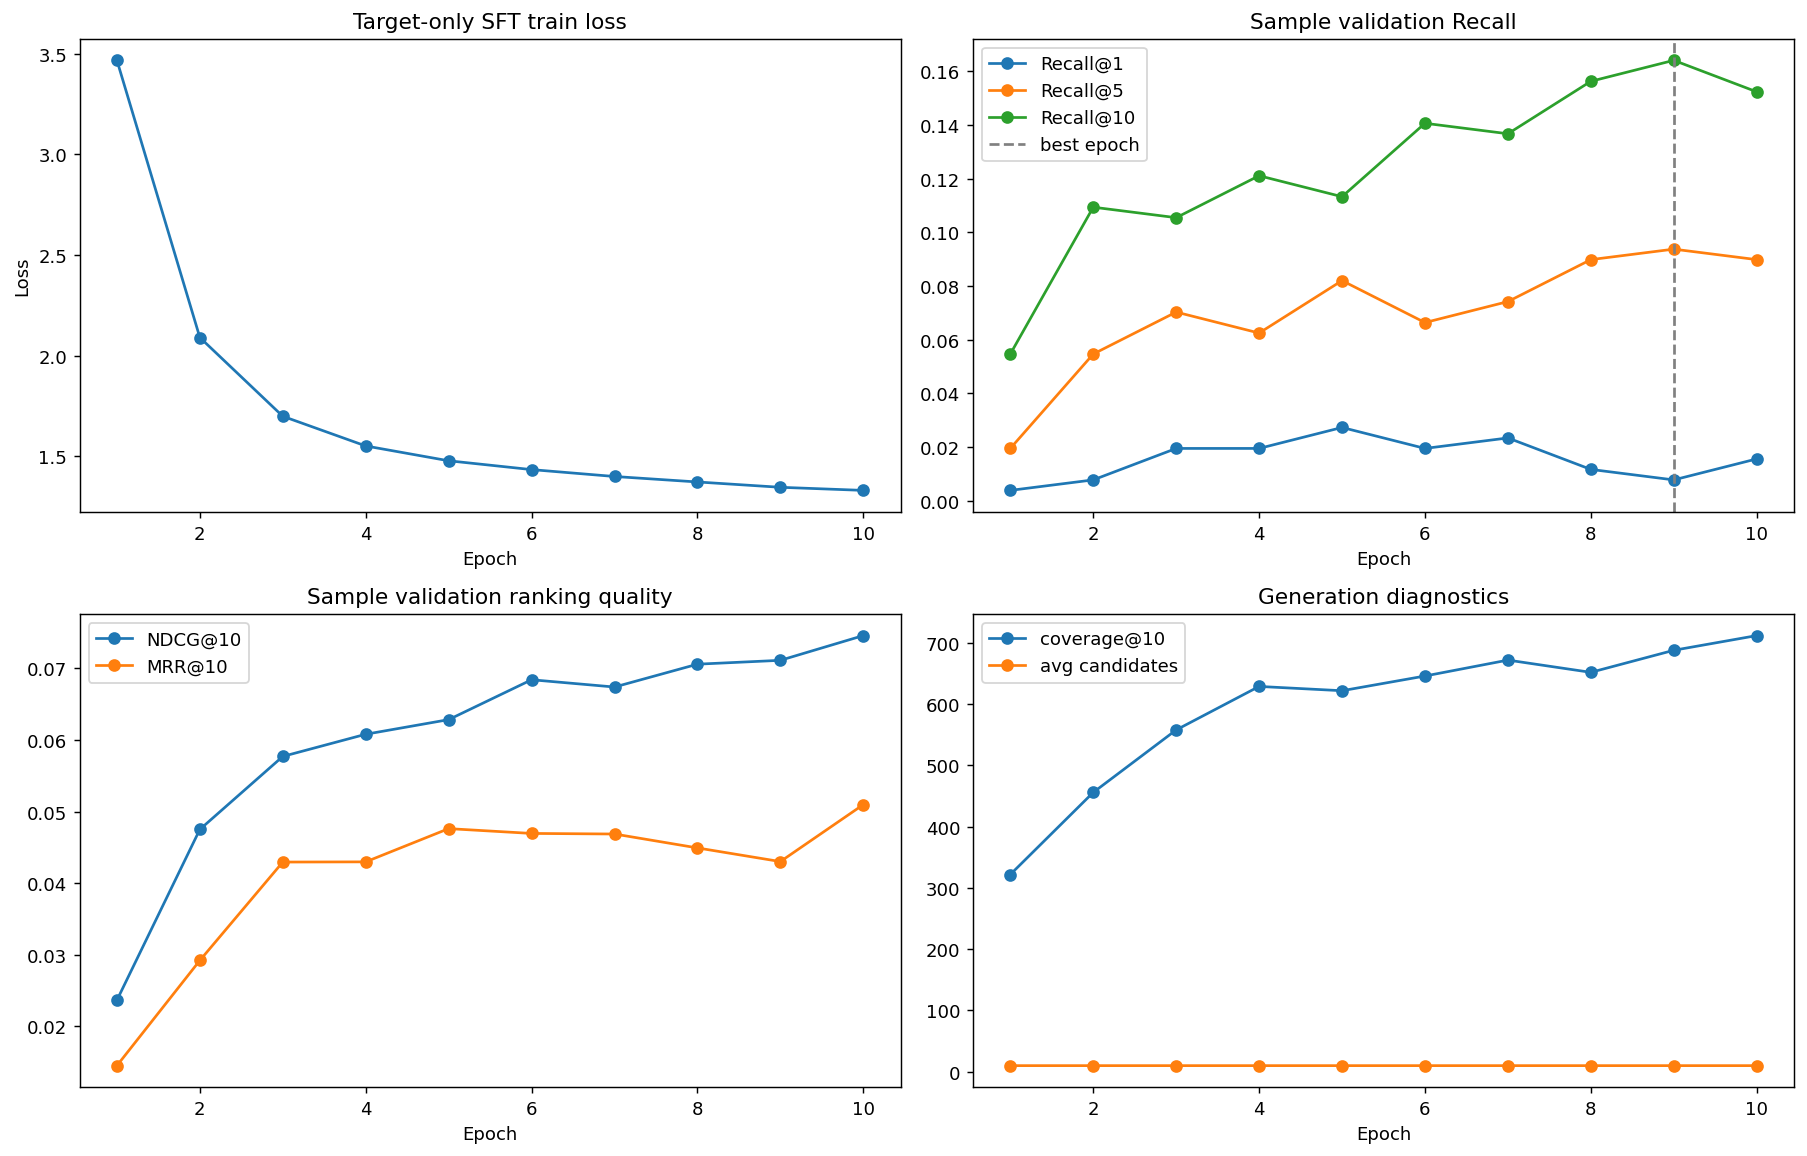

In [15]:
import matplotlib.pyplot as plt

metrics_df = pd.DataFrame(metrics_log)
if len(metrics_df):
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), dpi=130)
    axes[0, 0].plot(metrics_df["epoch"], metrics_df["train_loss"], marker="o")
    axes[0, 0].set_title("Target-only SFT train loss")
    axes[0, 0].set_xlabel("Epoch")
    axes[0, 0].set_ylabel("Loss")

    for k in [1, 5, 10]:
        col = f"eval_recall@{k}"
        if col in metrics_df:
            axes[0, 1].plot(metrics_df["epoch"], metrics_df[col], marker="o", label=f"Recall@{k}")
    axes[0, 1].axvline(best_epoch, color="gray", linestyle="--", label="best epoch")
    axes[0, 1].set_title("Sample validation Recall")
    axes[0, 1].set_xlabel("Epoch")
    axes[0, 1].legend()

    for col, label in [("eval_ndcg@10", "NDCG@10"), ("eval_mrr@10", "MRR@10")]:
        if col in metrics_df:
            axes[1, 0].plot(metrics_df["epoch"], metrics_df[col], marker="o", label=label)
    axes[1, 0].set_title("Sample validation ranking quality")
    axes[1, 0].set_xlabel("Epoch")
    axes[1, 0].legend()

    for col, label in [("eval_coverage@10", "coverage@10"), ("eval_avg_candidates", "avg candidates")]:
        if col in metrics_df:
            axes[1, 1].plot(metrics_df["epoch"], metrics_df[col], marker="o", label=label)
    axes[1, 1].set_title("Generation diagnostics")
    axes[1, 1].set_xlabel("Epoch")
    axes[1, 1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "sft_training_curves.png", bbox_inches="tight")
    plt.show()
else:
    print("No metrics yet.")

## 15. Quick inference examples

In [16]:
def render_prompt(example):
    return tokenizer.decode(example["input_ids"][:example["prompt_length"]], skip_special_tokens=False)

if BEST_ADAPTER_DIR.exists():
    ex = val_examples[0]
    gen = generate_candidates(model, ex, beam_size=EVAL_BEAM_SIZE, top_k=TOP_K)
    print(render_prompt(ex))
    print("target item_idx:", ex["target_item_idx"])
    print("candidates:", gen["candidates"])
else:
    print("Train first.")

<bos><task_rec><user><gen_M><age_45><occ_17></user><hist><e><sid_0_154><sid_1_99><sid_2_58><sid_3_44><rat_4></e><e><sid_0_154><sid_1_88><sid_2_114><sid_3_32><rat_4></e><e><sid_0_154><sid_1_191><sid_2_72><sid_3_37><rat_3></e><e><sid_0_154><sid_1_77><sid_2_55><sid_3_15><rat_4></e><e><sid_0_154><sid_1_21><sid_2_58><sid_3_39><rat_3></e><e><sid_0_453><sid_1_155><sid_2_44><sid_3_29><rat_3></e><e><sid_0_425><sid_1_249><sid_2_86><sid_3_34><rat_1></e><e><sid_0_139><sid_1_249><sid_2_117><sid_3_5><rat_2></e><e><sid_0_212><sid_1_18><sid_2_75><sid_3_30><rat_1></e><e><sid_0_470><sid_1_253><sid_2_56><sid_3_27><rat_3></e><e><sid_0_470><sid_1_233><sid_2_105><sid_3_33><rat_3></e><e><sid_0_442><sid_1_88><sid_2_85><sid_3_61><rat_3></e><e><sid_0_32><sid_1_175><sid_2_116><sid_3_17><rat_3></e><e><sid_0_139><sid_1_131><sid_2_52><sid_3_2><rat_4></e><e><sid_0_470><sid_1_88><sid_2_70><sid_3_26><rat_3></e><e><sid_0_438><sid_1_88><sid_2_41><sid_3_5><rat_4></e><next>
target item_idx: 525
candidates: [1094, 854, 853

## 16. Config snapshot

In [17]:
config = {
    "run_name": RUN_NAME,
    "base_model_dir": str(BASE_CPT_DIR),
    "uses_cpt": False,
    "ablation": "no_cpt_direct_sft",
    "sid_array_path": str(SID_ARRAY_PATH),
    "task": "next_watched_item_all_ratings",
    "target_only_loss": True,
    "use_dup_suffix": True,
    "max_epochs": MAX_EPOCHS,
    "min_epochs": MIN_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "primary_metric": PRIMARY_METRIC,
    "min_history_len": MIN_HISTORY_LEN,
    "train_history_window_choices": TRAIN_HISTORY_WINDOW_CHOICES,
    "train_window_policy": "single_fixed_window",
    "eval_history_len": EVAL_HISTORY_LEN,
    "max_seq_length": MAX_SEQ_LENGTH,
    "targets_per_user_per_epoch": TARGETS_PER_USER_PER_EPOCH,
    "eval_beam_size": EVAL_BEAM_SIZE,
    "top_k": TOP_K,
    "filter_seen": FILTER_SEEN,
    "eval_max_users": EVAL_MAX_USERS,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "per_device_batch": PER_DEVICE_BATCH,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "precision": PRECISION_MODE,
}
with (OUTPUT_DIR / "config.json").open("w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)
config

{'run_name': 'sft_qwen3_4b_no_cpt_sid_v2_next_watch_w16_pat2_v1',
 'base_model_dir': 'C:\\Users\\User\\.cache\\huggingface\\hub\\models--Qwen--Qwen3-4B-Base\\snapshots\\906bfd4b4dc7f14ee4320094d8b41684abff8539',
 'uses_cpt': False,
 'ablation': 'no_cpt_direct_sft',
 'sid_array_path': 'C:\\Users\\User\\plum-ml1m-repro\\runs\\qwen4b_rqvae_sid_v2_plum\\SIDs_best.npy',
 'task': 'next_watched_item_all_ratings',
 'target_only_loss': True,
 'use_dup_suffix': True,
 'max_epochs': 10,
 'min_epochs': 3,
 'early_stopping_patience': 2,
 'primary_metric': 'recall@10',
 'min_history_len': 16,
 'train_history_window_choices': [16],
 'train_window_policy': 'single_fixed_window',
 'eval_history_len': 16,
 'max_seq_length': 192,
 'targets_per_user_per_epoch': 4,
 'eval_beam_size': 20,
 'top_k': 10,
 'filter_seen': True,
 'eval_max_users': 256,
 'lora_r': 16,
 'lora_alpha': 32,
 'per_device_batch': 8,
 'gradient_accumulation_steps': 8,
 'precision': 'bf16'}